In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold
import itertools
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from scipy.spatial import distance
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score
import matplotlib.cm as cm
from scipy import linalg

%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [11]:
data = pd.read_csv('Data_Cortex_Nuclear_csv.csv')

In [12]:
print(data.shape)
data.head()

(1080, 82)


,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


In [13]:
#trganje na prvata i poslednite 4
data_clean = data.iloc[:, 1:-4]

In [14]:
print(data_clean.shape)
data_clean.head()

(1080, 77)


,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N
0,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,1.750936,...,0.188852,0.122652,NaN,0.106305,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652
1,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,1.596377,...,0.200404,0.116682,NaN,0.106592,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610
2,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,1.561316,...,0.193685,0.118508,NaN,0.108303,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427
3,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,1.595086,...,0.192112,0.132781,NaN,0.103184,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563
4,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,1.504230,...,0.205604,0.129954,NaN,0.104784,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730


In [17]:
data_clean.isnull().sum().sum()

np.int64(1396)

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
data_clean = pd.DataFrame(imputer.fit_transform(data_clean),
                        columns=data_clean.columns)

In [23]:
data_clean.isnull().sum().sum()

np.int64(0)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clean)

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

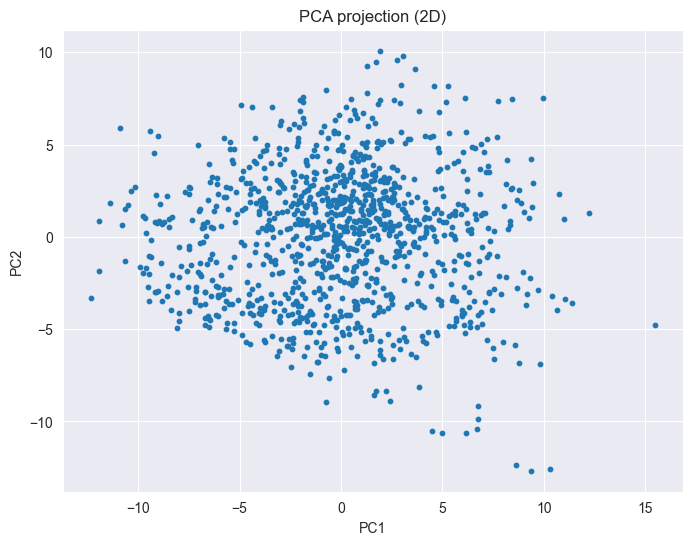

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0], data_pca[:,1], s=10)
plt.title("PCA projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [27]:
#K MEANS

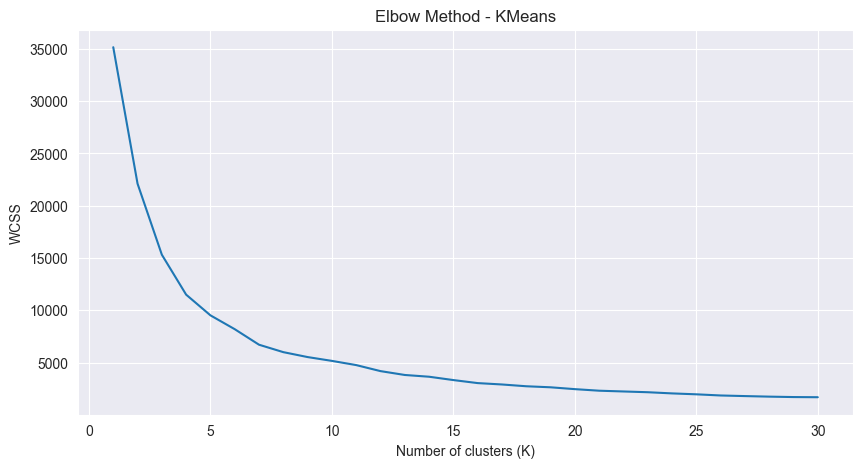

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 31):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=33)
    kmeans.fit(data_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,31), wcss)
plt.title('Elbow Method - KMeans')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

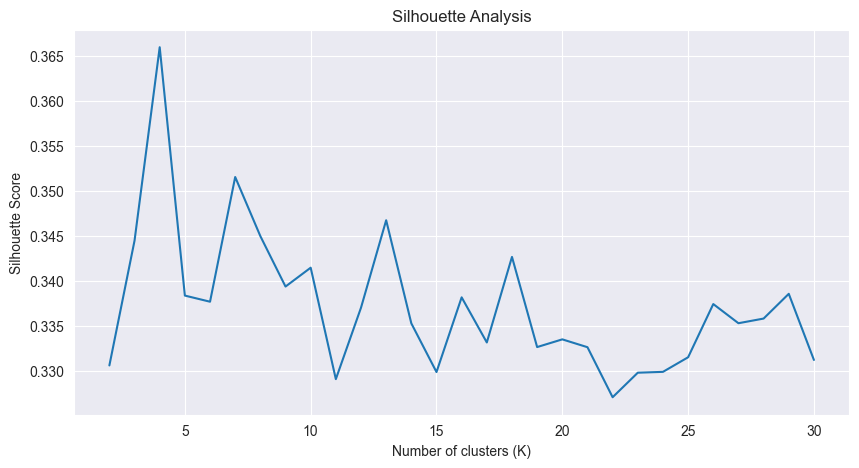

In [29]:
from sklearn.metrics import silhouette_score

silhouette_avg = []

range_n_clusters = range(2, 31)

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=33)
    cluster_labels = kmeans.fit_predict(data_pca)

    score = silhouette_score(data_pca, cluster_labels)
    silhouette_avg.append(score)

plt.figure(figsize=(10,5))
plt.plot(range_n_clusters, silhouette_avg)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

In [30]:
best_k = range_n_clusters[np.argmax(silhouette_avg)]
print(best_k)

4


In [31]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=33)
labels = kmeans.fit_predict(data_pca)

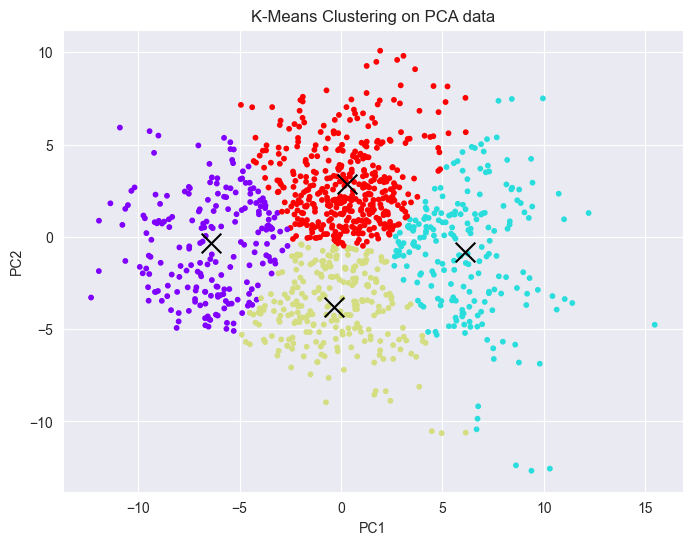

In [33]:
plt.figure(figsize=(8,6))

# points
plt.scatter(
    data_pca[:, 0],
    data_pca[:, 1],
    c=labels,
    cmap='rainbow',
    s=10
)

# centroids
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    s=200,
    marker='x'
)

plt.title('K-Means Clustering on PCA data')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

In [34]:
silhouette_score(data_pca, labels)

0.36600064701633434

In [52]:
#AGLOMERATIVE

In [53]:
#SINGLE LINKADE

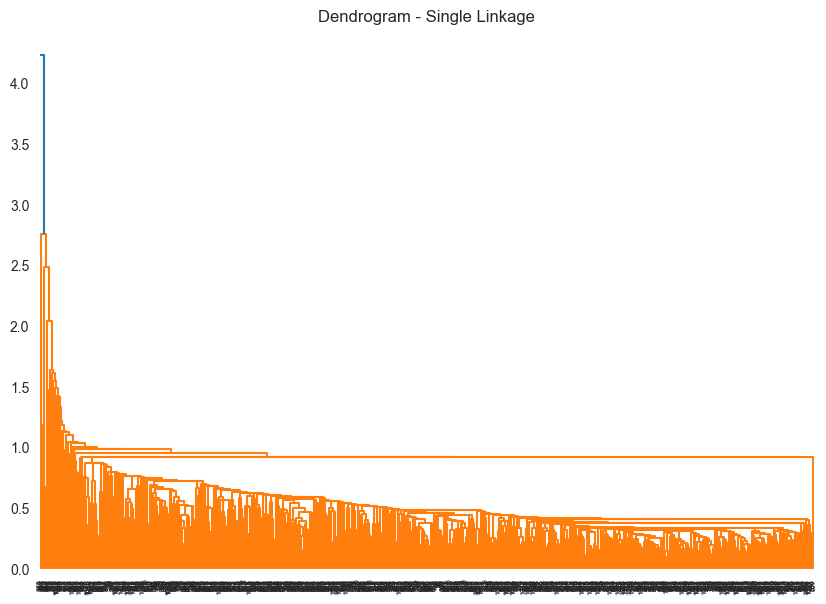

In [45]:
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Dendrogram - Single Linkage")

dend = shc.dendrogram(
    shc.linkage(data_pca, method='single')
)

plt.show()

In [47]:
from sklearn.cluster import AgglomerativeClustering

cluster2 = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='single'
)

labels_single = cluster2.fit_predict(data_pca)

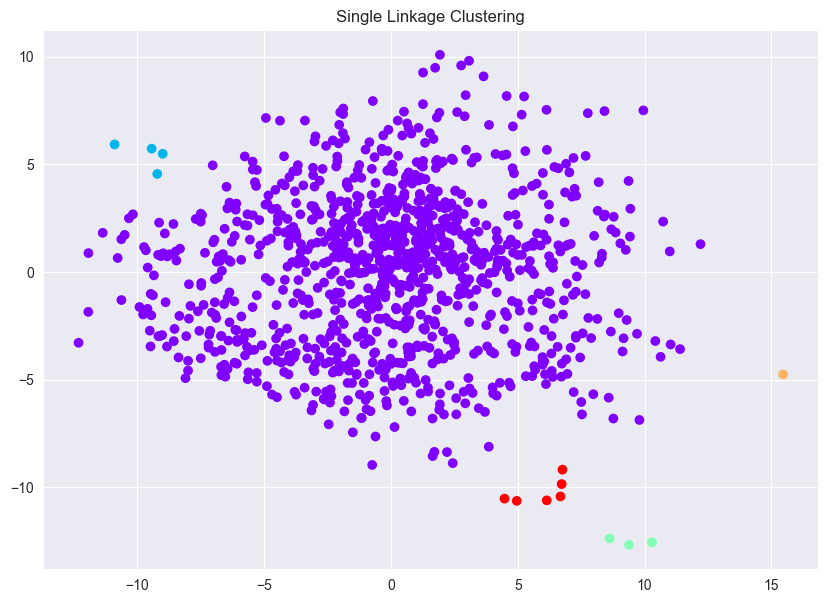

In [49]:
plt.figure(figsize=(10, 7))

plt.scatter(
    data_pca[:, 0],
    data_pca[:, 1],
    c=labels_single,
    cmap='rainbow'
)

plt.title("Single Linkage Clustering")
plt.show()

In [51]:
from sklearn.metrics import silhouette_score

score_single = silhouette_score(data_pca, labels_single)

print("Single Linkage Silhouette Score:", score_single)

Single Linkage Silhouette Score: 0.21701970302715246


In [79]:
from sklearn.metrics import calinski_harabasz_score

score_ward_ch = calinski_harabasz_score(data_pca, labels_single)

print("Single Linkage Calinski-Harabasz Score:", score_ward_ch)

Single Linkage Calinski-Harabasz Score: 19.12713997498086


In [85]:
from sklearn.metrics import davies_bouldin_score

dbi_ward = davies_bouldin_score(data_pca, labels_single)

print("Single Linkage Davies-Bouldin Index:", dbi_ward)

Single Linkage Davies-Bouldin Index: 0.4457015815821707


In [54]:
#COMPLETE

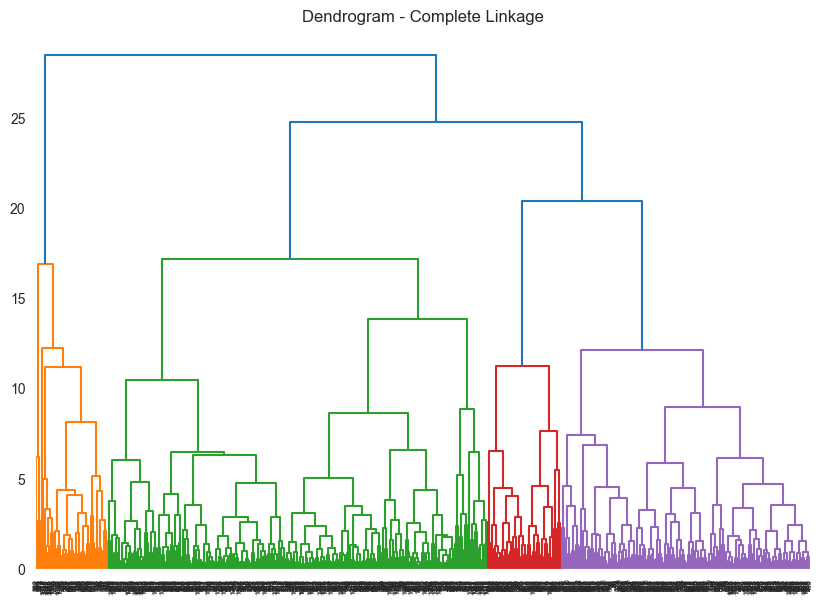

In [56]:
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Dendrogram - Complete Linkage")

dend = shc.dendrogram(
    shc.linkage(data_pca, method='complete')
)

plt.show()

In [57]:
from sklearn.cluster import AgglomerativeClustering

cluster3 = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='complete'
)

labels_complete = cluster3.fit_predict(data_pca)

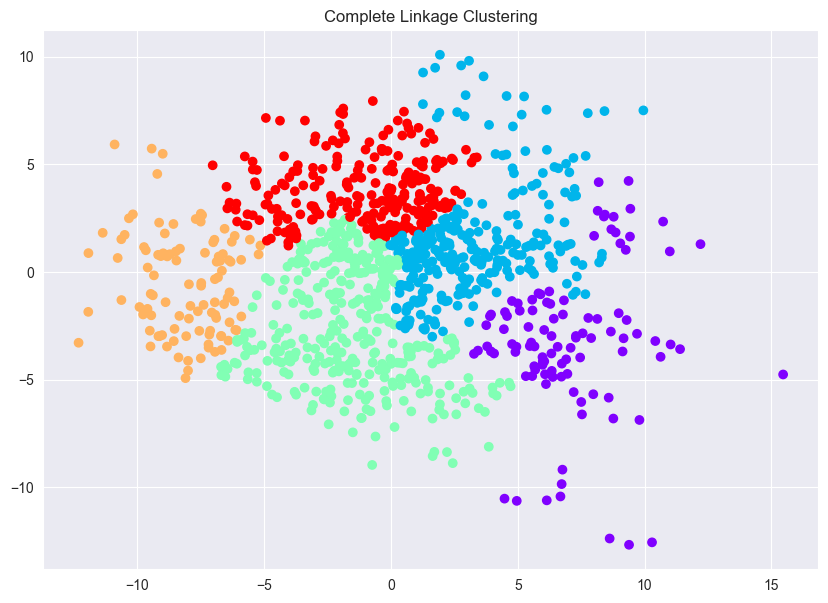

In [58]:
plt.figure(figsize=(10, 7))

plt.scatter(
    data_pca[:, 0],
    data_pca[:, 1],
    c=labels_complete,
    cmap='rainbow'
)

plt.title("Complete Linkage Clustering")
plt.show()

In [60]:
from sklearn.metrics import silhouette_score

score_complete = silhouette_score(data_pca, labels_complete)

print("Complete Linkage Silhouette Score:", score_complete)

Complete Linkage Silhouette Score: 0.2562842690613201


In [78]:
from sklearn.metrics import calinski_harabasz_score

score_ward_ch = calinski_harabasz_score(data_pca, labels_complete)

print("Complete Linkage Calinski-Harabasz Score:", score_ward_ch)

Complete Linkage Calinski-Harabasz Score: 528.4810335067395


In [86]:
from sklearn.metrics import davies_bouldin_score

dbi_ward = davies_bouldin_score(data_pca, labels_complete)

print("Complete Linkage Davies-Bouldin Index:", dbi_ward)

Complete Linkage Davies-Bouldin Index: 1.011953586072669


In [61]:
#AVERAGE LINKAGE

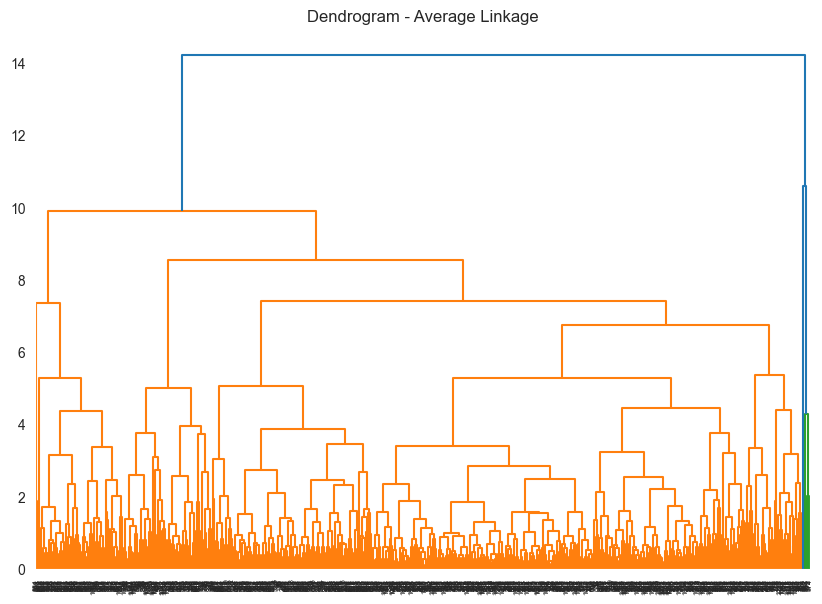

In [63]:
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Dendrogram - Average Linkage")

dend = shc.dendrogram(
    shc.linkage(data_pca, method='average')
)

plt.show()

In [65]:
from sklearn.cluster import AgglomerativeClustering

cluster_avg = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='average'
)

labels_avg = cluster_avg.fit_predict(data_pca)

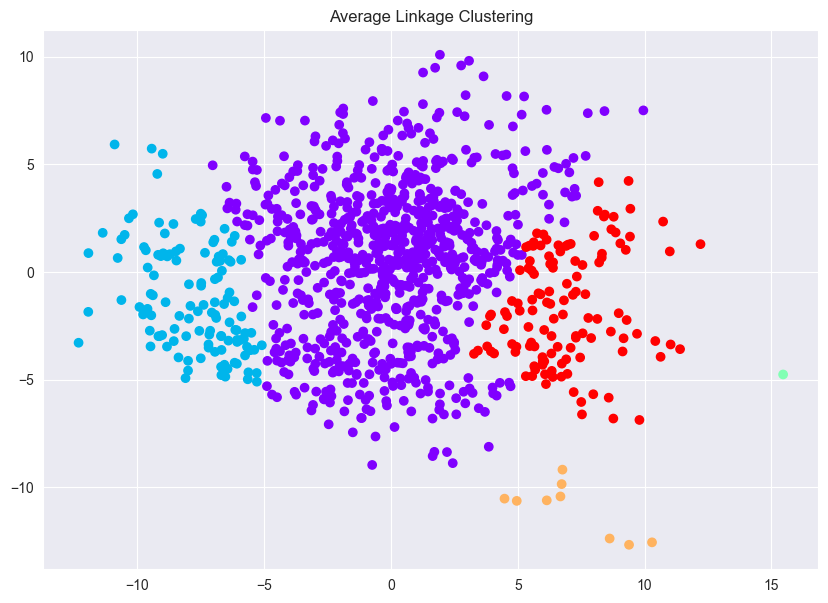

In [66]:
plt.figure(figsize=(10, 7))

plt.scatter(
    data_pca[:, 0],
    data_pca[:, 1],
    c=labels_avg,
    cmap='rainbow'
)

plt.title("Average Linkage Clustering")
plt.show()

In [68]:
from sklearn.metrics import silhouette_score

score_avg = silhouette_score(data_pca, labels_avg)
print("Average Linkage Silhouette Score:", score_avg)

Average Linkage Silhouette Score: 0.2467845997922766


In [77]:
from sklearn.metrics import calinski_harabasz_score

score_ward_ch = calinski_harabasz_score(data_pca, labels_avg)

print("Average Linkage Calinski-Harabasz Score:", score_ward_ch)

Average Linkage Calinski-Harabasz Score: 220.35630774470036


In [84]:
from sklearn.metrics import davies_bouldin_score

dbi_ward = davies_bouldin_score(data_pca, labels_avg)

print("Average Linkage Davies-Bouldin Index:", dbi_ward)

Average Linkage Davies-Bouldin Index: 0.7165556736719008


In [69]:
#WARD LINKAGE

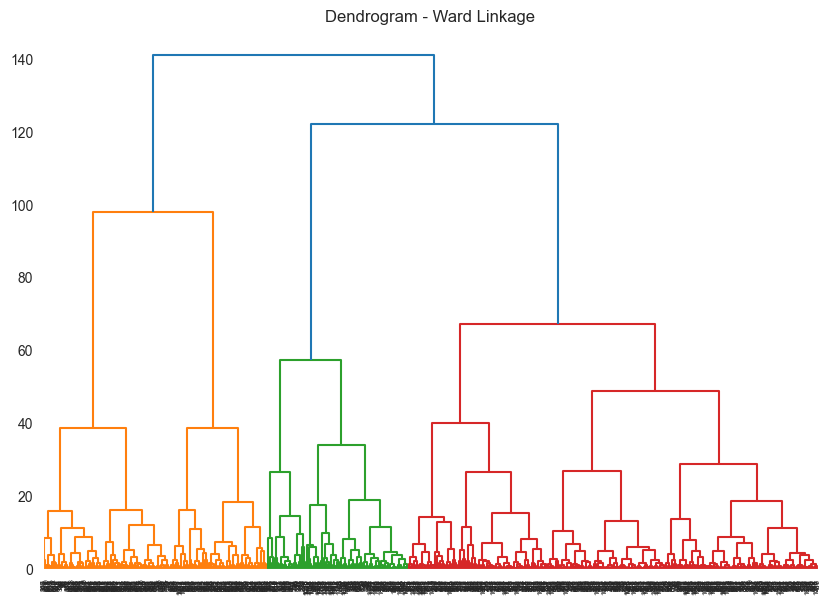

In [71]:
plt.figure(figsize=(10, 7))
plt.title("Dendrogram - Ward Linkage")

dend = shc.dendrogram(
    shc.linkage(data_pca, method='ward')
)

plt.show()

In [72]:
cluster_ward = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

labels_ward = cluster_ward.fit_predict(data_pca)

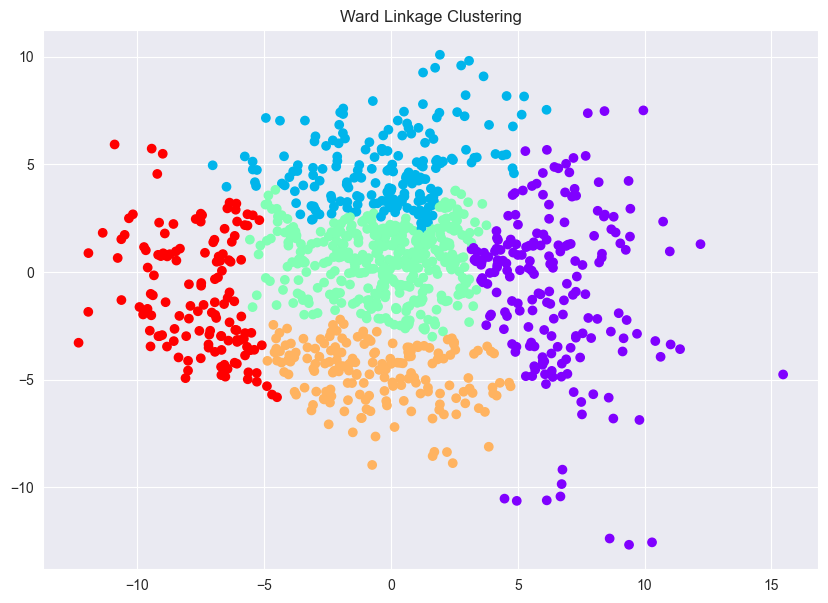

In [73]:
plt.figure(figsize=(10, 7))

plt.scatter(
    data_pca[:, 0],
    data_pca[:, 1],
    c=labels_ward,
    cmap='rainbow'
)

plt.title("Ward Linkage Clustering")
plt.show()

In [75]:
score_ward = silhouette_score(data_pca, labels_ward)
print("Ward Linkage Silhouette Score:", score_ward)

Ward Linkage Silhouette Score: 0.30263903167814865


In [76]:
from sklearn.metrics import calinski_harabasz_score

score_ward_ch = calinski_harabasz_score(data_pca, labels_ward)

print("Ward Linkage Calinski-Harabasz Score:", score_ward_ch)

Ward Linkage Calinski-Harabasz Score: 611.3221091388491


In [80]:
from sklearn.metrics import davies_bouldin_score

dbi_ward = davies_bouldin_score(data_pca, labels_ward)

print("Ward Linkage Davies-Bouldin Index:", dbi_ward)

Ward Linkage Davies-Bouldin Index: 0.9913782121318097
